In [1]:
import os
import sys
import json
import pickle
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns

# Switch to parent path to import local module
parent_path = str(os.getcwd()).split('notebooks')[0] # zeosyn_gen
os.chdir(parent_path)
print('Switched directory to:', os.getcwd())

import torch
import data.utils as utils
sys.modules['utils'] = utils # Way to get around relative imports in utils for ZeoSynGen_dataset # https://stackoverflow.com/questions/2121874/python-pickling-after-changing-a-modules-directory
from eval import load_model, get_prediction_and_ground_truths, eval_zeolite_aggregated, eval_zeolite_osda, plot_single_system
from data.metrics import maximum_mean_discrepancy, wasserstein_distance
from models.diffusion import *

plt.rc('font', family='Helvetica')

/home/synthesisproject/anaconda3/envs/zeo_diffusion_metrics_eq/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Switched directory to: /home/jupyter/Elton/Zeolites/zeosyn_gen


/home/synthesisproject/anaconda3/envs/zeo_diffusion_metrics_eq/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
zeo1, zeo1_osda = 'KFI', 'OSDA-free'
zeo2, zeo2_osda = 'ERI', 'OSDA-free'

In [3]:
model_type = 'diff'
fname = 'v3'
split = 'system'

# Load configs
with open(f'runs/{model_type}/{split}/{fname}/configs.json') as f:
    configs = json.load(f)
with open(f"runs/{model_type}/{split}/{fname}/train_loss_list.pkl", 'rb') as f: # load dataset
    train_loss_list = pickle.load(f)
with open(f"runs/{model_type}/{split}/{fname}/val_loss_list.pkl", 'rb') as f: # load dataset
    val_loss_list = pickle.load(f)

model, configs = load_model(model_type, fname, split)
syn_pred, syn_pred_scaled, syn_true, syn_true_scaled, dataset = get_prediction_and_ground_truths(model, configs, cond_scale=0.75, split='train')

Loading model and configs...
Loading model at runs/diff/system/v3/model.pt
Getting model predictions and grouth truths...
SYSTEMS:
train+val: 1856 test: 464

n_datapoints:
train: 14749 val: 2107 test: 5168
Loading synthetic predictions from saved predictions at runs/diff/system/v3/syn_pred_agg-cond_scale_0.75-train.csv


In [4]:
syn_pred

,Si/Al,Al/P,Si/Ge,Si/B,Na/T,K/T,OH/T,F/T,H2O/T,sda1/T,cryst_temp,cryst_time,zeo,osda
0,0.000000,1.000000,0.0,0.0,0.000000,0.000000,0.000000,0.5,0.000000,3.686546,150.0,6.00000,CHA,Cn1ccnc1
1,10.000000,1.717997,99.0,250.0,0.544060,0.000000,0.585431,0.0,10.000000,0.500000,125.0,89.21486,GME,OSDA-free
2,30.000000,1.717997,99.0,250.0,0.024777,0.000000,0.400000,0.0,15.151515,0.333333,100.0,168.00000,BEA,CC[N+](CC)(CC)CC
3,6.493506,1.717997,99.0,250.0,0.000000,0.000000,0.628926,0.0,27.247800,0.764456,200.0,168.00000,Dense/Amorphous,CC[N+](CC)(CC)CC
4,78.270430,1.717997,99.0,250.0,0.632418,0.000000,0.016817,0.0,19.426657,0.028325,170.0,48.00000,MFI,CCCC[N+](CC)(CC)CC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368720,0.300000,1.000000,99.0,250.0,0.000000,0.000000,0.000000,0.0,9.607612,0.435744,170.0,120.00000,FAU,CCC[N+](CCC)(CCC)CCC
368721,30.000000,1.717997,99.0,250.0,1.290861,0.000000,0.191491,0.0,40.000000,0.112338,170.0,72.00000,MFI,CCC[N+](CCC)(CCC)CCC
368722,34.967620,1.717997,99.0,250.0,0.334140,0.000000,0.233819,0.0,10.000000,0.000000,160.0,168.00000,NES,OSDA-free
368723,400.000000,0.000000,99.0,250.0,0.000000,0.168481,0.000000,0.5,3.500000,0.496783,175.0,336.00000,BEA,C[N+]1(C)CC2C3C=CC(CC3)C2C1


KFI OSDA-free


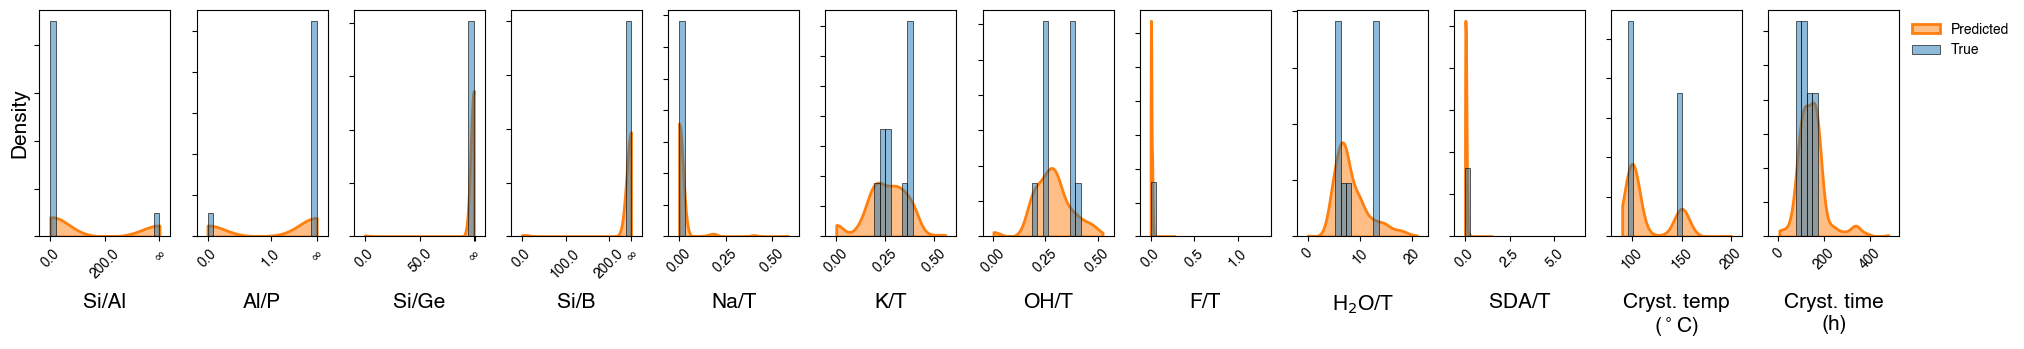

ERI OSDA-free


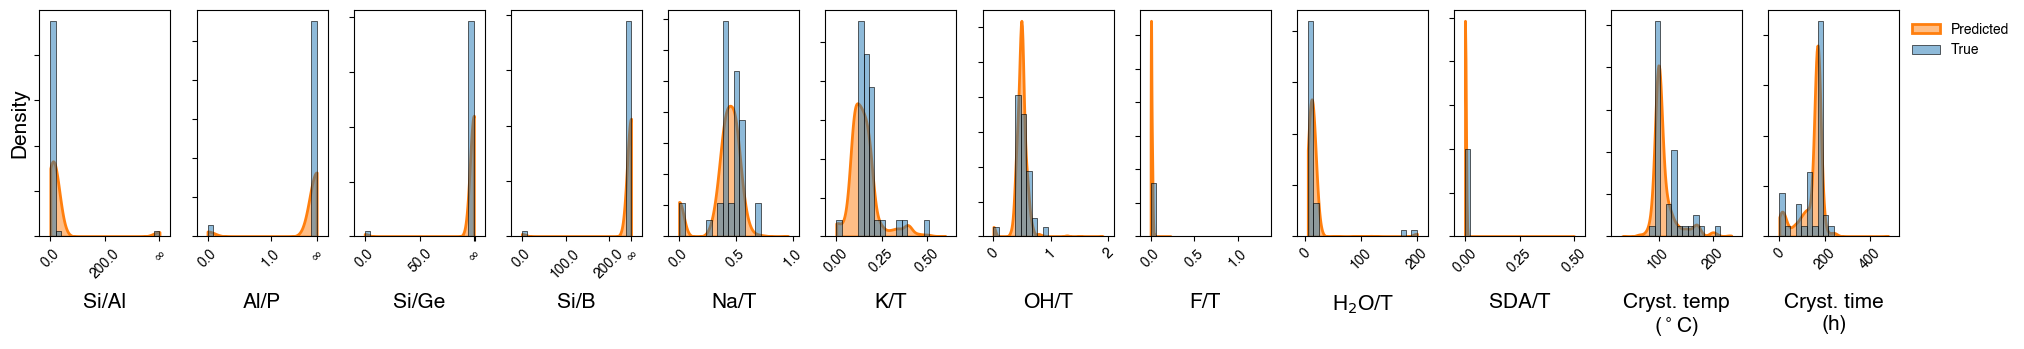

In [5]:
plot_single_system(syn_pred, syn_true, zeo=zeo1, osda=zeo1_osda)
plot_single_system(syn_pred, syn_true, zeo=zeo2, osda=zeo2_osda)

In [6]:
zeo1_pred, zeo1_true = syn_pred[(syn_pred['zeo'] == zeo1) & (syn_pred['osda'] == zeo1_osda)], syn_true[(syn_true['zeo'] == zeo1) & (syn_true['osda'] == zeo1_osda)]
zeo2_pred, zeo2_true = syn_pred[(syn_pred['zeo'] == zeo2) & (syn_pred['osda'] == zeo2_osda)], syn_true[(syn_true['zeo'] == zeo2) & (syn_true['osda'] == zeo2_osda)]

In [7]:
# Preprocess to unnormalized molar ratios
hets = ['Al', 'Ge', 'B']
thresholds = [0.00251, 0.099990, 0.004001]
for het, thres in zip(hets, thresholds):

    zeo1_true[f'{het}/Si'] = 1. / zeo1_true[f'Si/{het}']
    zeo1_true[f'{het}/Si'] = zeo1_true[f'{het}/Si'].map(lambda x: 1e-4 if x <= thres else x)
    zeo1_true[f'{het}'] = zeo1_true[f'{het}/Si']
    zeo1_true['Si'] = [1.]*len(zeo1_true)

    zeo1_pred[f'{het}/Si'] = 1. / zeo1_pred[f'Si/{het}']
    zeo1_pred[f'{het}/Si'] = zeo1_pred[f'{het}/Si'].map(lambda x: 1e-4 if x <= thres else x)
    zeo1_pred[f'{het}'] = zeo1_pred[f'{het}/Si']
    zeo1_pred['Si'] = [1.]*len(zeo1_pred)

tot_hets = zeo1_true[['Si']+hets].sum(1) # sum of heteroatoms fractions

for c in ['Na', 'K', 'OH', 'F', 'H2O', 'sda1']:
    zeo1_true[f'{c}'] = zeo1_true[f'{c}/T'] * tot_hets
    zeo1_true[f'{c}'] = zeo1_true[f'{c}'].map(lambda x: 1e-4 if x == 0. else x)
    zeo1_pred[f'{c}'] = zeo1_pred[f'{c}/T'] * tot_hets
    zeo1_pred[f'{c}'] = zeo1_pred[f'{c}'].map(lambda x: 1e-4 if x == 0. else x)

/tmp/ipykernel_2869957/598898482.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zeo1_true[f'{het}/Si'] = 1. / zeo1_true[f'Si/{het}']
/tmp/ipykernel_2869957/598898482.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zeo1_true[f'{het}/Si'] = zeo1_true[f'{het}/Si'].map(lambda x: 1e-4 if x <= thres else x)
/tmp/ipykernel_2869957/598898482.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

In [8]:
# Preprocess to unnormalized molar ratios
hets = ['Al', 'Ge', 'B']
thresholds = [0.00251, 0.099990, 0.004001]
for het, thres in zip(hets, thresholds):

    zeo2_true[f'{het}/Si'] = 1. / zeo2_true[f'Si/{het}']
    zeo2_true[f'{het}/Si'] = zeo2_true[f'{het}/Si'].map(lambda x: 1e-4 if x <= thres else x)
    zeo2_true[f'{het}'] = zeo2_true[f'{het}/Si']
    zeo2_true['Si'] = [1.]*len(zeo2_true)

    zeo2_pred[f'{het}/Si'] = 1. / zeo2_pred[f'Si/{het}']
    zeo2_pred[f'{het}/Si'] = zeo2_pred[f'{het}/Si'].map(lambda x: 1e-4 if x <= thres else x)
    zeo2_pred[f'{het}'] = zeo2_pred[f'{het}/Si']
    zeo2_pred['Si'] = [1.]*len(zeo2_pred)

tot_hets = zeo2_true[['Si']+hets].sum(1) # sum of heteroatoms fractions

for c in ['Na', 'K', 'OH', 'F', 'H2O', 'sda1']:
    zeo2_true[f'{c}'] = zeo2_true[f'{c}/T'] * tot_hets
    zeo2_true[f'{c}'] = zeo2_true[f'{c}'].map(lambda x: 1e-4 if x == 0. else x)
    zeo2_pred[f'{c}'] = zeo2_pred[f'{c}/T'] * tot_hets
    zeo2_pred[f'{c}'] = zeo2_pred[f'{c}'].map(lambda x: 1e-4 if x == 0. else x)

/tmp/ipykernel_2869957/2629124208.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zeo2_true[f'{het}/Si'] = 1. / zeo2_true[f'Si/{het}']
/tmp/ipykernel_2869957/2629124208.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zeo2_true[f'{het}/Si'] = zeo2_true[f'{het}/Si'].map(lambda x: 1e-4 if x <= thres else x)
/tmp/ipykernel_2869957/2629124208.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

In [ ]:
# Degree of freedoms
dofs = ['H2O', 'K', 'OH']

# Ternary diagram limits
ternary_lim = [0.85, 1.0, 0., 0.15, 0., 0.15] # set ternary_lim to None for full ternary diagram

/home/jupyter/Elton/Zeolites/zeosyn_gen/data/utils.py:811: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df_true[col] = _df_true[col] / norm
/home/jupyter/Elton/Zeolites/zeosyn_gen/data/utils.py:816: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df_pred[col] = _df_pred[col] / norm
/home/synthesisproject/.local/lib/python3.10/site-packages/pyrolite/comp/codata.py:176: RuntimeWarning: invalid value encountered in log
  Y = np.log(X)  # Log operation


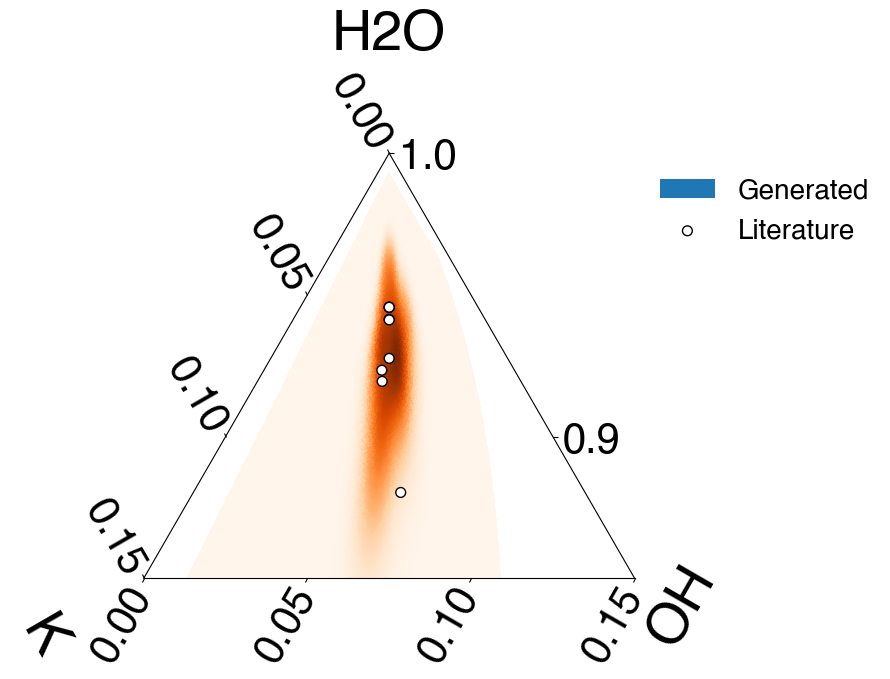

In [10]:
utils.plot_ternary(zeo1_true, zeo1_pred, dofs, ternary_lim=ternary_lim, n_bins=400, grid_border_frac=3, cmap='Oranges', markersize=50)

/home/jupyter/Elton/Zeolites/zeosyn_gen/data/utils.py:811: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df_true[col] = _df_true[col] / norm
/home/jupyter/Elton/Zeolites/zeosyn_gen/data/utils.py:816: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df_pred[col] = _df_pred[col] / norm
/home/synthesisproject/.local/lib/python3.10/site-packages/pyrolite/comp/codata.py:176: RuntimeWarning: invalid value encountered in log
  Y = np.log(X)  # Log operation


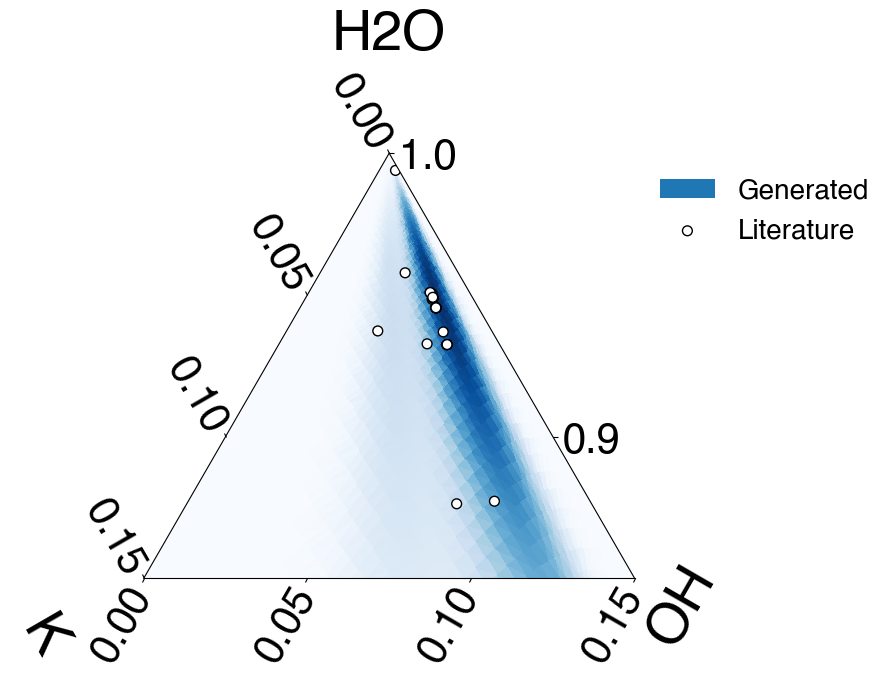

In [11]:
utils.plot_ternary(zeo2_true, zeo2_pred, dofs, ternary_lim=ternary_lim, n_bins=400, grid_border_frac=3, cmap='Blues', markersize=50)

/home/jupyter/Elton/Zeolites/zeosyn_gen/data/utils.py:867: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df_true[col] = _df_true[col] / norm
/home/jupyter/Elton/Zeolites/zeosyn_gen/data/utils.py:873: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df_pred[col] = _df_pred[col] / norm
/home/synthesisproject/.local/lib/python3.10/site-packages/pyrolite/comp/codata.py:176: RuntimeWarning: invalid value encountered in log
  Y = np.log(X)  # Log operation


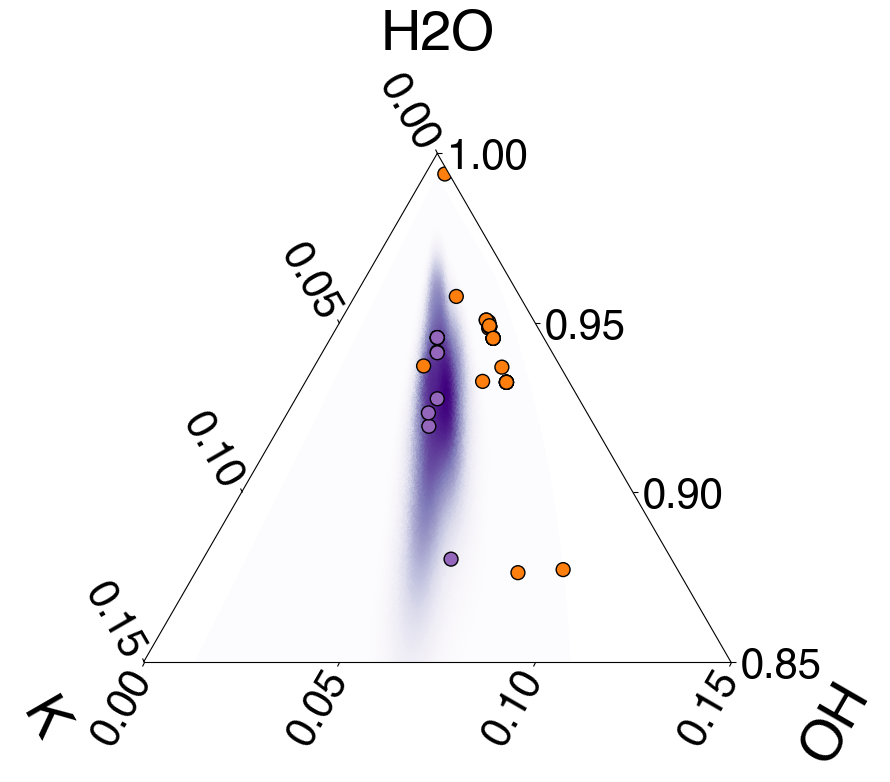

In [12]:
utils.plot_ternary_multiple([zeo1_true, zeo2_true], [zeo1_pred, zeo2_pred], dofs, [zeo1, zeo2], ternary_lim=ternary_lim, n_bins=400, grid_border_frac=3, cmaps=['Purples', 'Oranges'], cmap_alphas=[1., 0.], markersize=100, markeralphas=[1., 1.], markercolors=['tab:purple', 'tab:orange'], legend=False, 
                            save_path=f'figs/CP-CS2/{zeo1}.pdf'
                            )

/home/jupyter/Elton/Zeolites/zeosyn_gen/data/utils.py:867: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df_true[col] = _df_true[col] / norm
/home/jupyter/Elton/Zeolites/zeosyn_gen/data/utils.py:873: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df_pred[col] = _df_pred[col] / norm
/home/synthesisproject/.local/lib/python3.10/site-packages/pyrolite/comp/codata.py:176: RuntimeWarning: invalid value encountered in log
  Y = np.log(X)  # Log operation


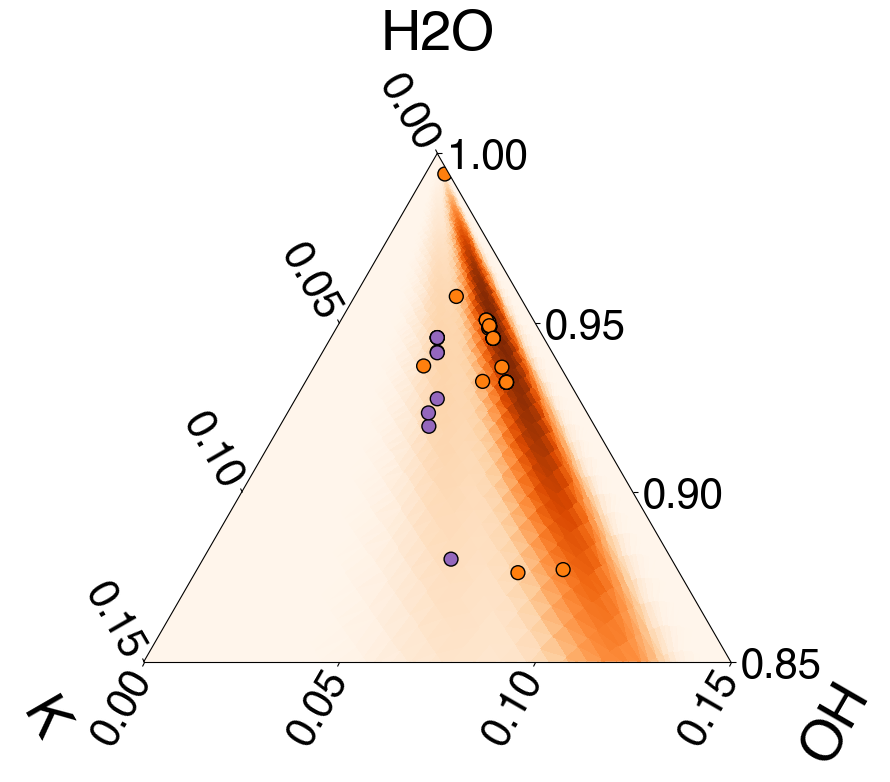

In [13]:
utils.plot_ternary_multiple([zeo1_true, zeo2_true], [zeo1_pred, zeo2_pred], dofs, [zeo1, zeo2], ternary_lim=ternary_lim, n_bins=400, grid_border_frac=3, cmaps=['Purples', 'Oranges'], cmap_alphas=[0., 1.], markersize=100, markeralphas=[1., 1.], markercolors=['tab:purple', 'tab:orange'], legend=False,
                            save_path=f'figs/CP-CS2/{zeo2}.pdf'
                            )

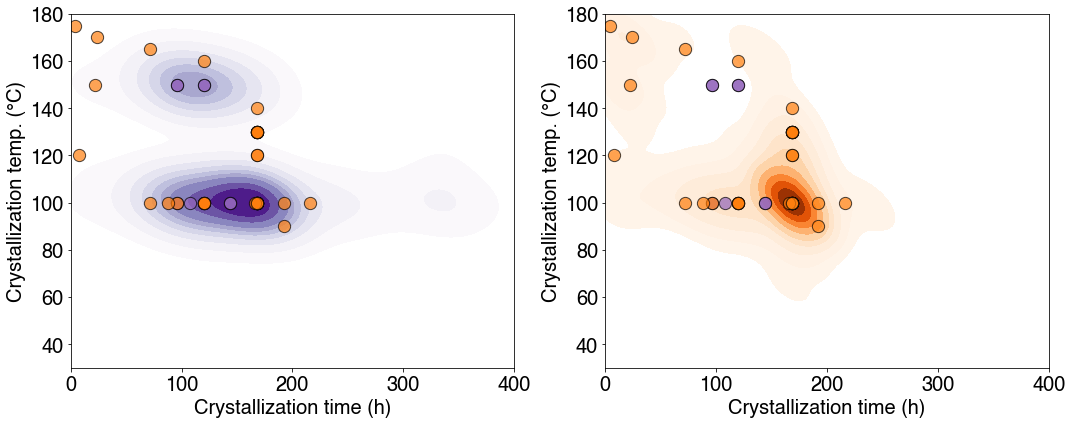

In [ ]:
# Plot phase diagram for temp and time

zeo1_temp_true, zeo1_temp_pred = zeo1_true['cryst_temp'], zeo1_pred['cryst_temp']
zeo2_temp_true, zeo2_temp_pred = zeo2_true['cryst_temp'], zeo2_pred['cryst_temp']

zeo1_time_true, zeo1_time_pred = zeo1_true['cryst_time'], zeo1_pred['cryst_time']
zeo2_time_true, zeo2_time_pred = zeo2_true['cryst_time'], zeo2_pred['cryst_time']

xlim=(30, 180)
ylim=(0, 400)

# Create a figure with subplots for both zeolites
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot for BEA (zeo1) - swapped x and y
sns.kdeplot(x=zeo1_time_pred, y=zeo1_temp_pred, ax=ax1, alpha=1., cmap='Purples', fill=True)
ax1.scatter(zeo1_time_true, zeo1_temp_true, c='tab:purple', alpha=0.7, s=150, label='Ground Truth', edgecolors='black', marker='o')
ax1.scatter(zeo2_time_true, zeo2_temp_true, c='tab:orange', alpha=0.7, s=150, label='Ground Truth', edgecolors='black', marker='o')
ax1.set_xlabel('Crystallization time (h)', fontsize=20)
ax1.set_ylabel('Crystallization temp. (°C)', fontsize=20)
ax1.set_xlim(*ylim)
ax1.set_ylim(*xlim)
ax1.tick_params(axis='both', which='major', labelsize=20)

# Plot for LTA (zeo2) - swapped x and y
sns.kdeplot(x=zeo2_time_pred, y=zeo2_temp_pred, ax=ax2, alpha=1., cmap='Oranges', fill=True)
ax2.scatter(zeo1_time_true, zeo1_temp_true, c='tab:purple', alpha=0.7, s=150, label='Ground Truth', edgecolors='black', marker='o')
ax2.scatter(zeo2_time_true, zeo2_temp_true, c='tab:orange', alpha=0.7, s=150, label='Ground Truth', edgecolors='black', marker='o')
ax2.set_xlabel('Crystallization time (h)', fontsize=20)
ax2.set_ylabel('Crystallization temp. (°C)', fontsize=20)
ax2.set_xlim(*ylim)
ax2.set_ylim(*xlim)
ax2.tick_params(axis='both', which='major', labelsize=20)

plt.tight_layout()
# plt.savefig(f'figs/CP-CS2/{zeo1}_{zeo2}_time_temp.pdf', dpi=300)
plt.show()